In [1]:
# Import necessary libraries    
!pip install pandas numpy scipy scikit-learn matplotlib seaborn


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Import necessary libraries

import pandas as pd
import numpy as np

from pathlib import Path

from scipy.stats import ttest_rel
from scipy.stats import wilcoxon

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Set random seed for reproducibility

import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

In [4]:
# Define paths

PROJECT_ROOT = Path.cwd().parent
RESULTS_DIR = PROJECT_ROOT / "results"

In [5]:
# Load model results

log_reg = pd.read_csv(RESULTS_DIR / "logistic_regression_results.csv")
naive_bayes = pd.read_csv(RESULTS_DIR / "naive_bayes_results.csv")
svm = pd.read_csv(RESULTS_DIR / "svm_baseline_results.csv")
finbert = pd.read_csv(RESULTS_DIR / "finbert_finetuned_results.csv")
finbert_tuned = pd.read_csv(RESULTS_DIR / "hyperparameter_tuning_finbert_predictions.csv")

In [6]:
print(log_reg.shape)
print(naive_bayes.shape)
print(svm.shape)
print(finbert.shape)
print(finbert_tuned.shape)

(400, 3)
(400, 3)
(400, 3)
(400, 3)
(400, 3)


In [7]:
# Add model labels for comparison

log_reg["model"] = "Logistic Regression"
naive_bayes["model"] = "Naive Bayes"
svm["model"] = "SVM"
finbert["model"] = "FinBERT"
finbert_tuned["model"] = "FinBERT Tuned"

In [8]:
# Check data types and sample data

for df, name in zip([log_reg, naive_bayes, svm, finbert, finbert_tuned],
                    ["log_reg","naive_bayes","svm","finbert","finbert_tuned"]):
    print(name)
    print(df.dtypes)
    print(df.head())

log_reg
text         object
Actual        int64
Predicted     int64
model        object
dtype: object
                                                text  Actual  Predicted  \
0  name ive been trying to call the customer serv...       0          0   
1  renew annual tpo and update certificate email ...       1          1   
2  assist with having the attached form executed ...       1          1   
3  i got a activation code after it got locked bt...       1          0   
4  app is not working for logging ini dont know w...       0          0   

                 model  
0  Logistic Regression  
1  Logistic Regression  
2  Logistic Regression  
3  Logistic Regression  
4  Logistic Regression  
naive_bayes
text         object
Actual       object
Predicted    object
model        object
dtype: object
                                                text    Actual Predicted  \
0  name ive been trying to call the customer serv...  negative  negative   
1  renew annual tpo and update certific

In [9]:
# Combine all results into a single DataFrame for comparison

all_results = pd.concat([
    log_reg,
    naive_bayes,
    svm,
    finbert,
    finbert_tuned
])

# Reset index after concatenation
all_results = all_results.reset_index(drop=True)

In [10]:
# Display the first few rows of the combined results

all_results.head()

,text,Actual,Predicted,model,actual_sentiment,predicted_sentiment
0,name ive been trying to call the customer serv...,0,0,Logistic Regression,NaN,NaN
1,renew annual tpo and update certificate email ...,1,1,Logistic Regression,NaN,NaN
2,assist with having the attached form executed ...,1,1,Logistic Regression,NaN,NaN
3,i got a activation code after it got locked bt...,1,0,Logistic Regression,NaN,NaN
4,app is not working for logging ini dont know w...,0,0,Logistic Regression,NaN,NaN


In [11]:
# Check the distribution of models in the combined results

all_results.groupby("model").size()

model
FinBERT                400
FinBERT Tuned          400
Logistic Regression    400
Naive Bayes            400
SVM                    400
dtype: int64

In [12]:
# Check unique values in the "Actual" column to confirm mapping

models = all_results["model"].unique()
print(models)

['Logistic Regression' 'Naive Bayes' 'SVM' 'FinBERT' 'FinBERT Tuned']


In [13]:
# Map string sentiment labels to numeric for Naive Bayes and SVM

sentiment_map_rev = {
    "Negative": 0, "neutral": 1, "positive": 2,
    "negative": 0, "Neutral": 1, "Positive": 2
}

for df in [naive_bayes, svm]:
    df["Actual"] = df["Actual"].map(sentiment_map_rev)
    df["Predicted"] = df["Predicted"].map(sentiment_map_rev)

# Rename columns in finbert_tuned to match others
finbert_tuned = finbert_tuned.rename(
    columns={"actual_sentiment": "Actual", "predicted_sentiment": "Predicted"}
)

# Quick check
print("Naive Bayes sample:\n", naive_bayes.head())
print("SVM sample:\n", svm.head())
print("FinBERT Tuned sample:\n", finbert_tuned.head())

Naive Bayes sample:
                                                 text  Actual  Predicted  \
0  name ive been trying to call the customer serv...       0          0   
1  renew annual tpo and update certificate email ...       1          1   
2  assist with having the attached form executed ...       1          1   
3  i got a activation code after it got locked bt...       1          0   
4  app is not working for logging ini dont know w...       0          0   

         model  
0  Naive Bayes  
1  Naive Bayes  
2  Naive Bayes  
3  Naive Bayes  
4  Naive Bayes  
SVM sample:
                                                 text  Actual  Predicted model
0  <Compressed Sparse Row sparse matrix of dtype ...       0          0   SVM
1  <Compressed Sparse Row sparse matrix of dtype ...       1          1   SVM
2  <Compressed Sparse Row sparse matrix of dtype ...       1          1   SVM
3  <Compressed Sparse Row sparse matrix of dtype ...       1          0   SVM
4  <Compressed Sparse R

In [14]:
# Combine all models into one DataFrame

all_results = pd.concat([log_reg, naive_bayes, svm, finbert, finbert_tuned])
all_results = all_results.reset_index(drop=True)

# Quick check
print("Combined results shape:", all_results.shape)
print("Models included:", all_results['model'].unique())

Combined results shape: (2000, 4)
Models included: ['Logistic Regression' 'Naive Bayes' 'SVM' 'FinBERT' 'FinBERT Tuned']


In [15]:
# Map numeric sentiment labels to descriptive labels for readability
sentiment_map = {0: "Negative", 1: "Neutral", 2: "Positive"}
all_results["actual_sentiment"] = all_results["Actual"].map(sentiment_map)
all_results["predicted_sentiment"] = all_results["Predicted"].map(sentiment_map)

# Check sample
all_results.head()

,text,Actual,Predicted,model,actual_sentiment,predicted_sentiment
0,name ive been trying to call the customer serv...,0,0,Logistic Regression,Negative,Negative
1,renew annual tpo and update certificate email ...,1,1,Logistic Regression,Neutral,Neutral
2,assist with having the attached form executed ...,1,1,Logistic Regression,Neutral,Neutral
3,i got a activation code after it got locked bt...,1,0,Logistic Regression,Neutral,Negative
4,app is not working for logging ini dont know w...,0,0,Logistic Regression,Negative,Negative


In [16]:
# Check counts per model
print(all_results.groupby("model")[["Actual","Predicted"]].count())

# Check unique values
print("Models:", all_results["model"].unique())
print("Actual values:", all_results["Actual"].unique())
print("Predicted values:", all_results["Predicted"].unique())

                     Actual  Predicted
model                                 
FinBERT                 400        400
FinBERT Tuned           400        400
Logistic Regression     400        400
Naive Bayes             400        400
SVM                     400        400
Models: ['Logistic Regression' 'Naive Bayes' 'SVM' 'FinBERT' 'FinBERT Tuned']
Actual values: [0 1 2]
Predicted values: [0 1 2]


In [17]:
# Map numeric sentiment labels to descriptive labels for readability

from sklearn.model_selection import RepeatedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Function to compute metrics for one fold
def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="weighted"),
        "recall": recall_score(y_true, y_pred, average="weighted"),
        "f1_score": f1_score(y_true, y_pred, average="weighted")
    }

# Set cross-validation: 10-fold, 3 repeats
rkf = RepeatedKFold(n_splits=10, n_repeats=3, random_state=SEED)

In [18]:
# Generate evaluation metrics for each model using repeated k-fold cross-validation

evaluation_results = []

for model_name in all_results["model"].unique():
    df_model = all_results[all_results["model"] == model_name].reset_index(drop=True)
    X = df_model.index.values.reshape(-1, 1)  # Dummy X, we only need y splits
    y = df_model["Actual"].values
    
    metrics_list = []
    
    for train_idx, test_idx in rkf.split(X):
        y_true = y[test_idx]
        y_pred = df_model["Predicted"].values[test_idx]
        
        metrics_list.append(compute_metrics(y_true, y_pred))
    
    # Convert to DataFrame and add model column
    metrics_df_model = pd.DataFrame(metrics_list)
    metrics_df_model["model"] = model_name
    
    evaluation_results.append(metrics_df_model)

# Concatenate all models' repeated metrics
metrics_df = pd.concat(evaluation_results).reset_index(drop=True)
metrics_df.head(10)

c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

,accuracy,precision,recall,f1_score,model
0,0.775,0.821795,0.775,0.773672,Logistic Regression
1,0.825,0.868750,0.825,0.817262,Logistic Regression
2,0.875,0.876780,0.875,0.875291,Logistic Regression
3,0.875,0.874838,0.875,0.874298,Logistic Regression
4,0.900,0.902950,0.900,0.898939,Logistic Regression
5,0.850,0.851190,0.850,0.848261,Logistic Regression
6,0.850,0.866061,0.850,0.848676,Logistic Regression
7,0.775,0.792407,0.775,0.768817,Logistic Regression
8,0.850,0.851442,0.850,0.847444,Logistic Regression
9,0.825,0.830000,0.825,0.825855,Logistic Regression


In [19]:
# Mean and standard deviation per model

metrics_summary = metrics_df.groupby("model").agg(
    mean_accuracy=("accuracy", "mean"),
    std_accuracy=("accuracy", "std"),
    mean_precision=("precision", "mean"),
    std_precision=("precision", "std"),
    mean_recall=("recall", "mean"),
    std_recall=("recall", "std"),
    mean_f1=("f1_score", "mean"),
    std_f1=("f1_score", "std")
).reset_index()

metrics_summary

,model,mean_accuracy,std_accuracy,mean_precision,std_precision,mean_recall,std_recall,mean_f1,std_f1
0,FinBERT,0.8700,0.047525,0.877020,0.043958,0.8700,0.047525,0.869951,0.047459
1,FinBERT Tuned,0.8625,0.049458,0.874412,0.046149,0.8625,0.049458,0.862829,0.050052
2,Logistic Regression,0.8400,0.058575,0.854770,0.052878,0.8400,0.058575,0.837901,0.060422
3,Naive Bayes,0.7450,0.068670,0.781431,0.071218,0.7450,0.068670,0.727524,0.077354
4,SVM,0.8575,0.058409,0.866429,0.054470,0.8575,0.058409,0.856767,0.058661


In [20]:
# Save metrics summary

# Save as CSV
metrics_df.to_csv(RESULTS_DIR / "metrics_repeated_cv.csv", index=False)

# Optional: save as Excel
metrics_df.to_excel(RESULTS_DIR / "metrics_repeated_cv.xlsx", index=False)

print("Full repeated metrics saved!")

Full repeated metrics saved!


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13444\2237086241.py:14: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13444\2237086241.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


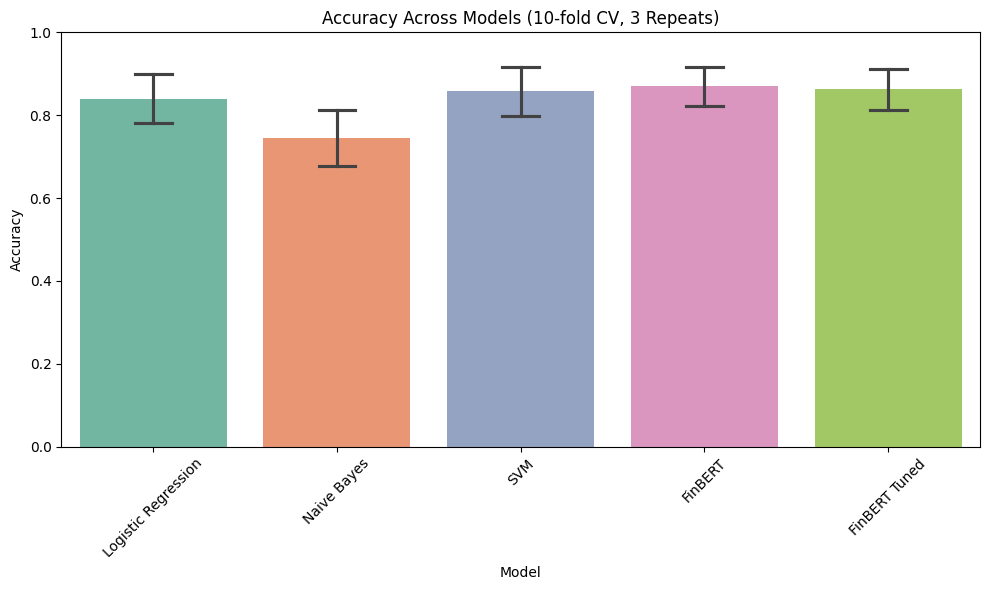

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13444\2237086241.py:14: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13444\2237086241.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


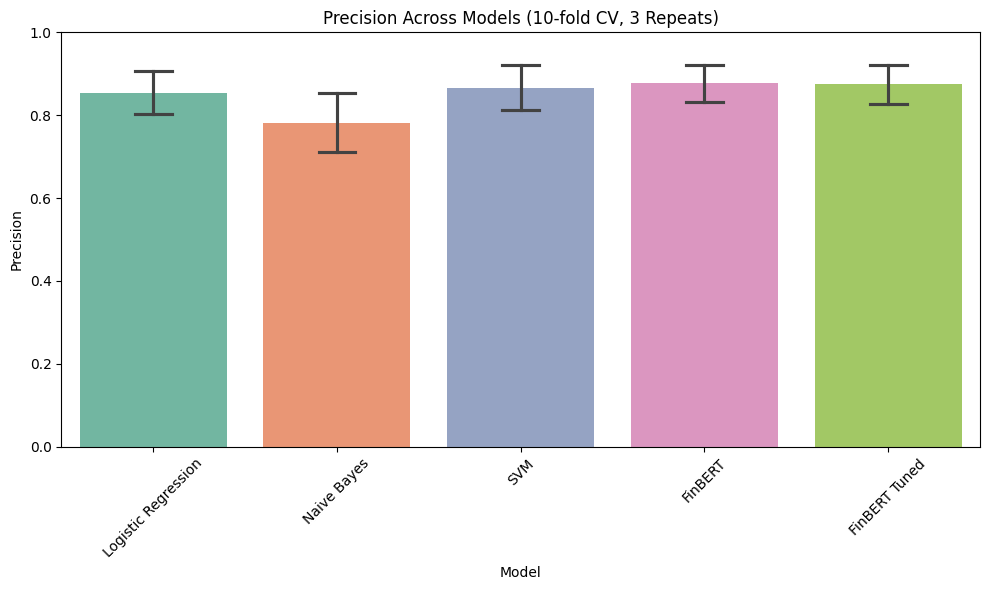

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13444\2237086241.py:14: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13444\2237086241.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


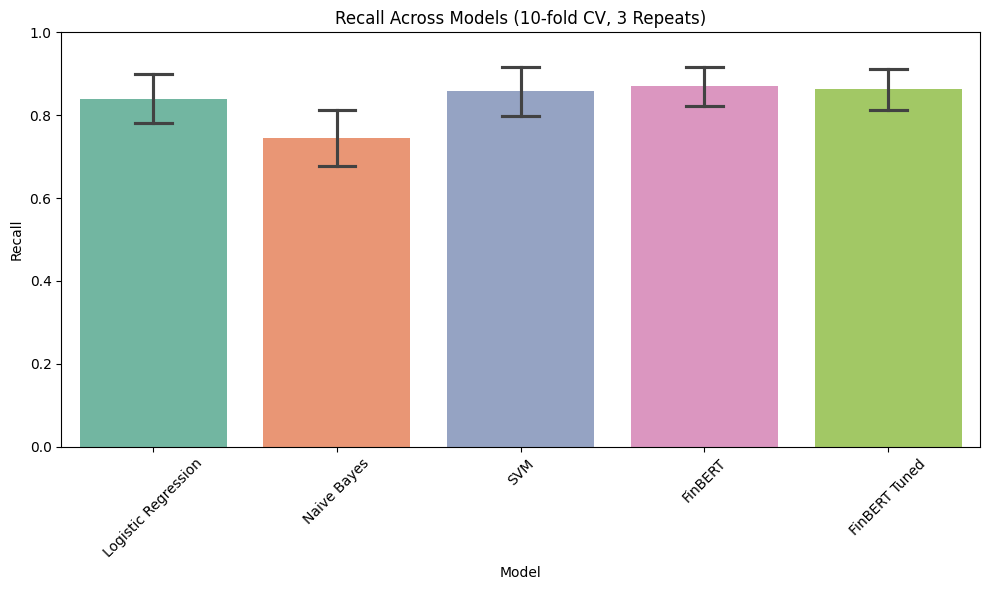

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13444\2237086241.py:14: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13444\2237086241.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


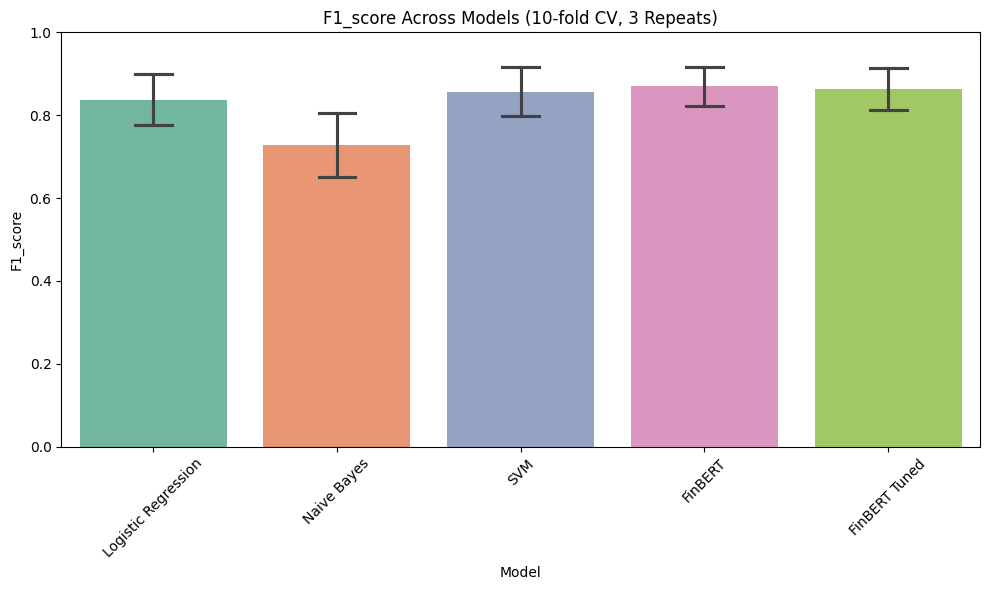

In [21]:
# Visualize the results with error bars (mean ± standard deviation)

import seaborn as sns
import matplotlib.pyplot as plt

# List of metrics to plot
metrics = ["accuracy", "precision", "recall", "f1_score"]

# Loop through metrics
for metric in metrics:
    plt.figure(figsize=(10, 6))
    
    # Use Seaborn barplot with standard deviation as error bars
    sns.barplot(
        x="model",
        y=metric,
        data=metrics_df,   # full repeated CV metrics (30 samples per model)
        ci="sd",           # automatically shows mean ± SD
        capsize=0.2,
        palette="Set2"
    )
    
    plt.title(f"{metric.capitalize()} Across Models (10-fold CV, 3 Repeats)")
    plt.ylabel(metric.capitalize())
    plt.xlabel("Model")
    plt.xticks(rotation=45)
    plt.ylim(0, 1)  # assuming metrics are between 0 and 1
    plt.tight_layout()
    
    # Save the figure
    plt.savefig(RESULTS_DIR / f"{metric}_barplot.png")
    
    plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13444\2763823062.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13444\2763823062.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13444\2763823062.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13444\2763823062.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13444\2763823062.py:15: FutureWarning: 

The `ci` parameter is depr

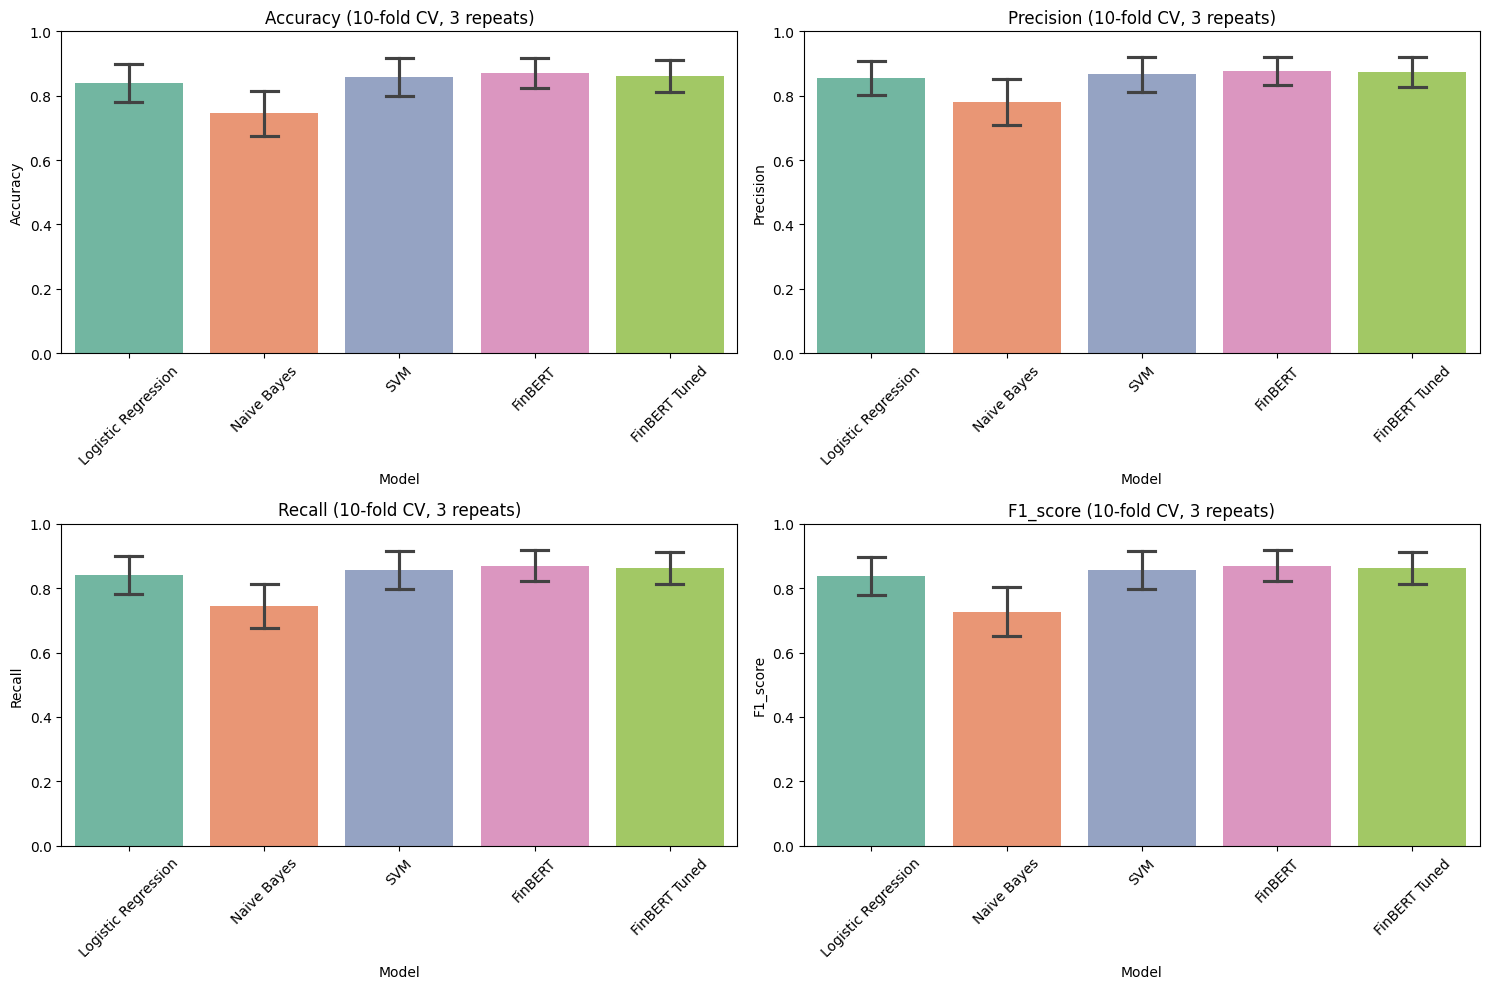

In [22]:
# Combined plot for all metrics

import matplotlib.pyplot as plt
import seaborn as sns

# Metrics to plot
metrics = ["accuracy", "precision", "recall", "f1_score"]

# Set up figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()  # flatten to easily iterate

# Loop through metrics and axes
for i, metric in enumerate(metrics):
    sns.barplot(
        x="model",
        y=metric,
        data=metrics_df,
        ci="sd",           # mean ± standard deviation
        capsize=0.2,
        palette="Set2",
        ax=axes[i]
    )
    axes[i].set_title(f"{metric.capitalize()} (10-fold CV, 3 repeats)")
    axes[i].set_xlabel("Model")
    axes[i].set_ylabel(metric.capitalize())
    axes[i].set_ylim(0, 1)  # metrics range between 0 and 1
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()

# Save the combined figure
fig.savefig(RESULTS_DIR / "all_metrics_barplot.png", dpi=300)

plt.show()